# Fase 2 — EDA y limpieza de datos

**Objetivo:** Unificar las 6 fuentes de datos en un único dataset `matches_clean.csv` limpio, normalizado y enriquecido con variables derivadas, listo para la fase de modelado.

| Dataset | Descripción | Filas |
|---------|-------------|-------|
| `results.csv` | Partidos internacionales 1872–2026 | ~49 k |
| `goalscorers.csv` | Goles individuales | ~47 k |
| `shootouts.csv` | Tandas de penaltis | 677 |
| `fifa_ranking.csv` | Ranking FIFA sep-2020 → sep-2025 | 7.6 k |
| `elo_ratings.csv` | Ratings Elo (snapshot 2026-05-09) | 244 |
| `wc2026_groups.csv` | 48 equipos clasificados al Mundial 2026 | 48 |

**Entregable:** `data/processed/matches_clean.csv`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='Set2')
C = sns.color_palette('Set2')

DATA_RAW  = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(exist_ok=True)

## 1. Carga de datos brutos

In [2]:
results     = pd.read_csv(DATA_RAW / 'results.csv',      parse_dates=['date'])
goalscorers = pd.read_csv(DATA_RAW / 'goalscorers.csv',  parse_dates=['date'])
shootouts   = pd.read_csv(DATA_RAW / 'shootouts.csv',    parse_dates=['date'])
fifa_rank   = pd.read_csv(DATA_RAW / 'fifa_ranking.csv', parse_dates=['ranking_date'])
elo         = pd.read_csv(DATA_RAW / 'elo_ratings.csv',  encoding='latin-1')
wc2026      = pd.read_csv(DATA_RAW / 'wc2026_groups.csv')

# Fix ELO encoding issues (Curaçao stored as latin-1 bytes)
elo['team'] = elo['team'].apply(
    lambda x: x.encode('latin-1').decode('utf-8', errors='replace') if isinstance(x, str) else x
)

print('Datasets cargados:')
for name, df in [('results', results), ('goalscorers', goalscorers), ('shootouts', shootouts),
                 ('fifa_rank', fifa_rank), ('elo', elo), ('wc2026', wc2026)]:
    nulls = df.isnull().sum().sum()
    print(f'  {name:15s}: {df.shape[0]:>7,} filas x {df.shape[1]:>2} cols | nulls: {nulls}')

Datasets cargados:
  results        :  49,328 filas x  9 cols | nulls: 144
  goalscorers    :  47,601 filas x  8 cols | nulls: 304
  shootouts      :     677 filas x  5 cols | nulls: 430
  fifa_rank      :   7,576 filas x  7 cols | nulls: 17
  elo            :     244 filas x  5 cols | nulls: 1
  wc2026         :      48 filas x  5 cols | nulls: 0


## 2. Exploración inicial de cada dataset

In [3]:
# results.csv — dataset principal
print('=== results.csv ===')
display(results.head(3))
display(results.dtypes.rename('dtype').to_frame())
print(f'\nRango de fechas : {results["date"].min().date()} → {results["date"].max().date()}')
print(f'Torneos únicos  : {results["tournament"].nunique()}')
all_teams_raw = pd.concat([results['home_team'], results['away_team']]).unique()
print(f'Equipos únicos  : {len(all_teams_raw)}')
print(f'Valores neutral : {dict(results["neutral"].value_counts())}')

=== results.csv ===


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.00,0.00,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.00,2.00,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.00,1.00,Friendly,Glasgow,Scotland,False


,dtype
date,datetime64[us]
home_team,str
away_team,str
home_score,float64
away_score,float64
tournament,str
city,str
country,str
neutral,bool



Rango de fechas : 1872-11-30 → 2026-06-27
Torneos únicos  : 198
Equipos únicos  : 336
Valores neutral : {False: np.int64(36270), True: np.int64(13058)}


In [4]:
print('=== shootouts.csv ===')
display(shootouts.head(3))
display(shootouts.dtypes.rename('dtype').to_frame())

print('\n=== fifa_ranking.csv ===')
display(fifa_rank.head(3))
print(f'Rango de fechas : {fifa_rank["ranking_date"].min().date()} → {fifa_rank["ranking_date"].max().date()}')
print(f'Snapshots       : {fifa_rank["ranking_date"].nunique()}')
print(f'Confederaciones : {sorted(fifa_rank["confederation"].unique())}')

print('\n=== elo_ratings.csv ===')
display(elo.head(3))
print(f'Rating range    : {elo["elo_rating"].min()} → {elo["elo_rating"].max()}')

print('\n=== wc2026_groups.csv ===')
display(wc2026)

=== shootouts.csv ===


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN


,dtype
date,datetime64[us]
home_team,str
away_team,str
winner,str
first_shooter,str



=== fifa_ranking.csv ===


,date_id,ranking_date,rank,team,country_code,points,confederation
0,13043,2020-09-17,1.00,Belgium,BEL,1773.00,UEFA
1,13043,2020-09-17,2.00,France,FRA,1744.00,UEFA
2,13043,2020-09-17,3.00,Brazil,BRA,1712.00,CONMEBOL


Rango de fechas : 2020-09-17 → 2025-09-18
Snapshots       : 36
Confederaciones : ['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']

=== elo_ratings.csv ===


,rank,code,team,elo_rating,peak_elo
0,1,ES,Spain,2165,2189
1,2,AR,Argentina,2113,2172
2,3,FR,France,2082,2135


Rating range    : 369 → 2165

=== wc2026_groups.csv ===


,group,team,confederation,host_country,pot
0,A,Mexico,CONCACAF,Yes,1
1,A,South Korea,AFC,No,2
2,A,South Africa,CAF,No,3
3,A,Czech Republic,UEFA,No,4
4,B,Canada,CONCACAF,Yes,1
5,B,Switzerland,UEFA,No,2
6,B,Bosnia and Herzegovina,UEFA,No,3
7,B,Qatar,AFC,No,4
8,C,United States,CONCACAF,Yes,1
9,C,Turkey,UEFA,No,2


In [5]:
# Valores nulos por columna
print('Valores nulos por columna:')
for name, df in [('results', results), ('goalscorers', goalscorers), ('shootouts', shootouts),
                 ('fifa_rank', fifa_rank), ('elo', elo), ('wc2026', wc2026)]:
    ndf = df.isnull().sum()
    if ndf.sum() > 0:
        print(f'\n  {name}:')
        for col, n in ndf[ndf > 0].items():
            pct = n / len(df) * 100
            print(f'    {col:30s}: {n:>5,} ({pct:.1f}%)')
    else:
        print(f'  {name}: sin nulos')

Valores nulos por columna:

  results:
    home_score                    :    72 (0.1%)
    away_score                    :    72 (0.1%)

  goalscorers:
    scorer                        :    48 (0.1%)
    minute                        :   256 (0.5%)

  shootouts:
    first_shooter                 :   430 (63.5%)

  fifa_rank:
    rank                          :    17 (0.2%)

  elo:
    code                          :     1 (0.4%)
  wc2026: sin nulos


## 3. Normalización de nombres de selecciones

El dataset `results.csv` abarca 1872-2026 e incluye equipos históricos que ya no existen (Yugoslavia, Checoslovaquia, etc.) o con nombres distintos a los usados en otras fuentes.

**Estrategia:**
1. `TEAM_NAME_MAP` — normaliza results.csv hacia nombres canónicos (consistentes con wc2026_groups.csv)
2. `FIFA_NAME_MAP` — puente entre nombres canónicos y los usados por FIFA ranking
3. `ELO_NAME_MAP`  — puente entre nombres canónicos y los usados por ELO ratings

**Criterios para fusiones políticas:**  
- Equipos sucesores heredan el historial del predecesor (Yugoslavia → Serbia, Checoslovaquia → Czech Republic).  
- Esta es una simplificación necesaria para el modelado; se documenta aquí para trazabilidad.

In [6]:
# Equipos históricos / no estándar presentes en results.csv
all_teams_sorted = sorted(pd.concat([results['home_team'], results['away_team']]).unique())
print(f'Total equipos únicos en results.csv: {len(all_teams_sorted)}')

historical_keywords = [
    'Soviet', 'Yugoslav', 'Czechoslov', 'Zaire', 'German',
    'CIS', 'China PR', 'Republic of Ireland', 'FR Yugoslavia',
    'Serbia and Montenegro', 'Rhodesia', 'Western Samoa',
    'Burma', 'Dahomey', 'Upper Volta', 'Kampuchea', 'Dutch East',
    'Timor', 'Vietnam Republic', 'North Vietnam', 'Macedonia', 'Cape Verde Islands',
]

print('\nNombres históricos / no estándar encontrados:')
for t in all_teams_sorted:
    if any(k.lower() in t.lower() for k in historical_keywords):
        n = results[(results['home_team'] == t) | (results['away_team'] == t)].shape[0]
        print(f'  {t!r:45s} ({n:>4} partidos)')

Total equipos únicos en results.csv: 336

Nombres históricos / no estándar encontrados:
  'China PR'                                    ( 700 partidos)
  'Czechoslovakia'                              ( 520 partidos)
  'German DR'                                   ( 298 partidos)
  'Germany'                                     (1032 partidos)
  'North Macedonia'                             ( 304 partidos)
  'North Vietnam'                               (  24 partidos)
  'Republic of Ireland'                         ( 630 partidos)
  'Timor-Leste'                                 (  86 partidos)
  'Vietnam Republic'                            ( 195 partidos)
  'Yugoslavia'                                  ( 483 partidos)


In [7]:
# Verificar equipos WC2026 vs results.csv
wc_teams     = set(wc2026['team'].unique())
result_teams = set(pd.concat([results['home_team'], results['away_team']]).unique())

missing = wc_teams - result_teams
if missing:
    print('WC2026 teams NOT in results.csv (requieren mapeo):')
    for t in sorted(missing):
        print(f'  {t!r}')
else:
    print(f'✓ Los 48 equipos WC2026 aparecen en results.csv con el mismo nombre exacto.')
    print('  No se requiere pre-mapeo para los equipos clasificados.')

✓ Los 48 equipos WC2026 aparecen en results.csv con el mismo nombre exacto.
  No se requiere pre-mapeo para los equipos clasificados.


In [8]:
# ── Mapa principal: results.csv → nombres canónicos ─────────────────────
TEAM_NAME_MAP = {
    # Reunificación alemana (oct 1990) — results.csv ya usa 'Germany' pero incluimos por trazabilidad
    'West Germany': 'Germany',
    'East Germany': 'Germany',

    # Disolución URSS (dic 1991)
    'Soviet Union': 'Russia',
    'CIS': 'Russia',             # CEI jugó brevemente en 1992

    # Sucesión yugoslava
    'Yugoslavia': 'Serbia',
    'FR Yugoslavia': 'Serbia',   # República Federal (Serbia+Montenegro) 1994-2003
    'Serbia and Montenegro': 'Serbia',

    # Checoslovaquia (escisión ene 1993)
    'Czechoslovakia': 'Czech Republic',

    # Estados renombrados
    'Zaire': 'DR Congo',
    'Congo DR': 'DR Congo',
    'Burma': 'Myanmar',
    'Swaziland': 'Eswatini',
    'Western Samoa': 'Samoa',
    'Southern Rhodesia': 'Zimbabwe',
    'Rhodesia': 'Zimbabwe',
    'Dahomey': 'Benin',
    'Upper Volta': 'Burkina Faso',
    'Kampuchea': 'Cambodia',
    'Dutch East Indies': 'Indonesia',
    'Timor-Leste': 'East Timor',

    # Estandarización de nombres (→ consistente con wc2026_groups.csv)
    'China PR': 'China',
    'Republic of Ireland': 'Ireland',
    'FYR Macedonia': 'North Macedonia',
    'Macedonia': 'North Macedonia',
    'Bosnia Herzegovina': 'Bosnia and Herzegovina',
    'Cape Verde Islands': 'Cape Verde',
    'Vietnam Republic': 'Vietnam',
    'North Vietnam': 'Vietnam',
}

# ── Puente hacia FIFA ranking (FIFA usa nombres distintos) ───────────────
FIFA_NAME_MAP = {
    'Iran': 'IR Iran',
    'South Korea': 'Korea Republic',
    'North Korea': 'Korea DPR',
    'United States': 'USA',
    'Ivory Coast': "Côte d'Ivoire",
    'Cape Verde': 'Cabo Verde',
    'DR Congo': 'Congo DR',
    'China': 'China PR',
    'Ireland': 'Republic of Ireland',
}

# ── Puente hacia ELO ratings ─────────────────────────────────────────────
ELO_NAME_MAP = {
    'Czech Republic': 'Czechia',
}

print(f'TEAM_NAME_MAP : {len(TEAM_NAME_MAP)} entradas')
print(f'FIFA_NAME_MAP : {len(FIFA_NAME_MAP)} entradas')
print(f'ELO_NAME_MAP  : {len(ELO_NAME_MAP)} entradas')

TEAM_NAME_MAP : 28 entradas
FIFA_NAME_MAP : 9 entradas
ELO_NAME_MAP  : 1 entradas


In [9]:
# Aplicar normalización a results.csv
df = results.copy()
df['home_team'] = df['home_team'].replace(TEAM_NAME_MAP)
df['away_team'] = df['away_team'].replace(TEAM_NAME_MAP)

# Mostrar cambios aplicados
changed = {}
for old, new in TEAM_NAME_MAP.items():
    n_before = results[(results['home_team'] == old) | (results['away_team'] == old)].shape[0]
    if n_before > 0:
        changed[old] = (new, n_before)

if changed:
    print('Renombres aplicados:')
    for old, (new, n) in sorted(changed.items(), key=lambda x: -x[1][1]):
        print(f'  {old!r:40s} → {new!r:30s}  ({n} partidos afectados)')
else:
    print('Ninguna entrada del TEAM_NAME_MAP encontrada en results.csv.')
    print('El dataset ya tiene los nombres normalizados en la mayoría de casos.')

print(f'\nEquipos únicos antes: {len(result_teams)}')
new_teams = set(pd.concat([df['home_team'], df['away_team']]).unique())
print(f'Equipos únicos después: {len(new_teams)}')

Renombres aplicados:
  'China PR'                               → 'China'                         (700 partidos afectados)
  'Republic of Ireland'                    → 'Ireland'                       (630 partidos afectados)
  'Czechoslovakia'                         → 'Czech Republic'                (520 partidos afectados)
  'Yugoslavia'                             → 'Serbia'                        (483 partidos afectados)
  'Vietnam Republic'                       → 'Vietnam'                       (195 partidos afectados)
  'Timor-Leste'                            → 'East Timor'                    (86 partidos afectados)
  'North Vietnam'                          → 'Vietnam'                       (24 partidos afectados)

Equipos únicos antes: 336


Equipos únicos después: 332


In [10]:
# Verificar cobertura de WC2026 tras normalización
new_teams = set(pd.concat([df['home_team'], df['away_team']]).unique())
still_missing = wc_teams - new_teams
if still_missing:
    print('WC2026 teams aún sin match:')
    for t in sorted(still_missing):
        print(f'  {t!r}')
else:
    print(f'✓ Los 48 equipos WC2026 tienen cobertura histórica en results.csv.')

# Verificar equipos FIFA ranking y ELO
latest_fifa = fifa_rank[fifa_rank['ranking_date'] == fifa_rank['ranking_date'].max()].copy()
latest_fifa['team_canonical'] = latest_fifa['team'].replace(
    {v: k for k, v in FIFA_NAME_MAP.items()}
)
fifa_teams_canonical = set(latest_fifa['team_canonical'].unique())

print(f'\nEquipos WC2026 en FIFA ranking (snapshot {fifa_rank["ranking_date"].max().date()}):')
for t in sorted(wc_teams):
    found = t in fifa_teams_canonical or FIFA_NAME_MAP.get(t) in latest_fifa['team'].values
    status = '✓' if found else '✗'
    if not found:
        print(f'  {status} {t!r}')
print(f'  (Solo se muestran los no encontrados; el resto ✓)')

✓ Los 48 equipos WC2026 tienen cobertura histórica en results.csv.

Equipos WC2026 en FIFA ranking (snapshot 2025-09-18):
  ✗ 'Czech Republic'
  ✗ 'Turkey'
  (Solo se muestran los no encontrados; el resto ✓)


## 4. Construcción del dataset unificado `matches`

Pasos:
1. Merge con `shootouts.csv` (detectar si el partido fue a penaltis)
2. Variables derivadas: resultado, diferencia de goles, año, década
3. Clasificación del torneo
4. Confederación de cada equipo
5. FIFA rank más reciente (snapshot 2025-09)
6. Rating Elo actual (snapshot 2026-05-09)

In [11]:
# 4.1 Merge con shootouts
so = shootouts[["date", "home_team", "away_team", "winner"]].copy()
so.columns = ["date", "home_team", "away_team", "shootout_winner"]

# Aplicar misma normalización a shootouts (China PR, Czechoslovakia, Republic of Ireland, etc.)
so["home_team"]       = so["home_team"].replace(TEAM_NAME_MAP)
so["away_team"]       = so["away_team"].replace(TEAM_NAME_MAP)
so["shootout_winner"] = so["shootout_winner"].replace(TEAM_NAME_MAP)

matches = df.merge(so, on=["date", "home_team", "away_team"], how="left")
matches["had_shootout"] = matches["shootout_winner"].notna()

# Codificar ganador de penaltis como home/away
matches["shootout_home_won"] = np.where(
    matches["had_shootout"],
    matches["shootout_winner"] == matches["home_team"],
    np.nan
)

print(f"Partidos con tanda de penaltis: {matches["had_shootout"].sum()}")
print(f"Partidos sin penaltis         : {(~matches["had_shootout"]).sum()}")
print(f"Total filas tras merge        : {len(matches)}")
print(f"Shootouts sin match (non-FIFA) : {len(shootouts) - matches["had_shootout"].sum()}")

Partidos con tanda de penaltis: 676
Partidos sin penaltis         : 48652
Total filas tras merge        : 49328
Shootouts sin match (non-FIFA) : 1


In [12]:
# 4.2 Variables derivadas
matches['year']      = matches['date'].dt.year
matches['decade']    = (matches['year'] // 10) * 10
matches['goal_diff'] = matches['home_score'] - matches['away_score']
matches['total_goals'] = matches['home_score'] + matches['away_score']

# Resultado del partido (considerando solo el tiempo reglamentario + prórroga)
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'H'
    elif row['home_score'] < row['away_score']:
        return 'A'
    else:
        return 'D'

matches['result'] = matches.apply(get_result, axis=1)

print('Distribución de resultados:')
print(matches['result'].value_counts())

Distribución de resultados:
result
H    24129
A    13925
D    11274
Name: count, dtype: int64


In [13]:
# 4.3 Clasificación del tipo de torneo
def classify_tournament(t):
    t_l = t.lower()
    if t_l == 'fifa world cup':
        return 'World Cup'
    if 'world cup' in t_l and 'qual' in t_l:
        return 'WC Qualification'
    if t_l == 'friendly':
        return 'Friendly'
    if any(x in t_l for x in [
        'copa am', 'uefa euro ', 'african cup of nations', 'afc asian cup',
        'gold cup', 'afcon', 'nations cup of africa', 'concacaf championship'
    ]):
        if 'qual' in t_l:
            return 'Continental Qualification'
        return 'Continental Championship'
    if any(x in t_l for x in ['nations league', 'nations cup', 'conf. cup', 'confederations cup']):
        return 'Nations League / Conf. Cup'
    if 'qual' in t_l:
        return 'Other Qualification'
    return 'Other'

matches['tournament_type'] = matches['tournament'].apply(classify_tournament)
matches['is_world_cup']    = matches['tournament_type'] == 'World Cup'
matches['is_friendly']     = matches['tournament_type'] == 'Friendly'
matches['is_competitive']  = ~matches['is_friendly']

print('Distribución por tipo de torneo:')
print(matches['tournament_type'].value_counts().to_string())

Distribución por tipo de torneo:
tournament_type
Friendly                      18256
Other                         10001
WC Qualification               8772
Continental Qualification      6227
Continental Championship       2724
Nations League / Conf. Cup     1482
World Cup                      1036
Other Qualification             830


In [14]:
# 4.4 Confederación por equipo
# Fuente primaria: FIFA ranking (más reciente por equipo)
conf_from_fifa = (
    fifa_rank.sort_values('ranking_date')
    .groupby('team')[['confederation']]
    .last()
    .reset_index()
)
# Traducir nombres FIFA → canónicos
FIFA_REVERSE = {v: k for k, v in FIFA_NAME_MAP.items()}
conf_from_fifa['team_canonical'] = conf_from_fifa['team'].replace(FIFA_REVERSE)
conf_dict = dict(zip(conf_from_fifa['team_canonical'], conf_from_fifa['confederation']))

# Añadir confederaciones de wc2026 (para equipos que no estén en FIFA ranking)
for _, row in wc2026.iterrows():
    if row['team'] not in conf_dict:
        conf_dict[row['team']] = row['confederation']

# Manual para equipos históricos importantes
HISTORIC_CONF = {
    'Serbia': 'UEFA', 'Yugoslavia': 'UEFA', 'Soviet Union': 'UEFA',
    'Russia': 'UEFA', 'Czechoslovakia': 'UEFA', 'Czech Republic': 'UEFA',
    'North Macedonia': 'UEFA', 'Montenegro': 'UEFA', 'Kosovo': 'UEFA',
    'Bosnia and Herzegovina': 'UEFA', 'Scotland': 'UEFA', 'Wales': 'UEFA',
    'Northern Ireland': 'UEFA', 'Georgia': 'UEFA', 'Armenia': 'UEFA',
    'Azerbaijan': 'UEFA', 'Belarus': 'UEFA', 'Moldova': 'UEFA',
    'Estonia': 'UEFA', 'Latvia': 'UEFA', 'Lithuania': 'UEFA',
    'Kazakhstan': 'UEFA', 'Iceland': 'UEFA', 'Cyprus': 'UEFA',
    'Malta': 'UEFA', 'Luxembourg': 'UEFA', 'Liechtenstein': 'UEFA',
    'Andorra': 'UEFA', 'San Marino': 'UEFA', 'Gibraltar': 'UEFA',
    'Faroe Islands': 'UEFA', 'Slovakia': 'UEFA', 'Slovenia': 'UEFA',
    'Ukraine': 'UEFA', 'Bulgaria': 'UEFA', 'Romania': 'UEFA',
    'Denmark': 'UEFA', 'Finland': 'UEFA', 'Hungary': 'UEFA',
    'Greece': 'UEFA', 'Albania': 'UEFA',
    'Bolivia': 'CONMEBOL', 'Chile': 'CONMEBOL', 'Peru': 'CONMEBOL',
    'Venezuela': 'CONMEBOL', 'Ecuador': 'CONMEBOL',
    'Jamaica': 'CONCACAF', 'Costa Rica': 'CONCACAF', 'Honduras': 'CONCACAF',
    'El Salvador': 'CONCACAF', 'Cuba': 'CONCACAF', 'Haiti': 'CONCACAF',
    'Guatemala': 'CONCACAF', 'Trinidad & Tobago': 'CONCACAF', 'Suriname': 'CONCACAF',
    'Belize': 'CONCACAF', 'Nicaragua': 'CONCACAF', 'Dominican Republic': 'CONCACAF',
    'Curaçao': 'CONCACAF', 'Bermuda': 'CONCACAF',
    'Cameroon': 'CAF', 'Nigeria': 'CAF', 'Zambia': 'CAF', 'Zimbabwe': 'CAF',
    'DR Congo': 'CAF', 'Angola': 'CAF', 'Tanzania': 'CAF', 'Kenya': 'CAF',
    'Uganda': 'CAF', 'Ethiopia': 'CAF', 'Sudan': 'CAF', 'Mali': 'CAF',
    'Togo': 'CAF', 'Liberia': 'CAF', 'Sierra Leone': 'CAF',
    'South Africa': 'CAF', 'Ivory Coast': 'CAF', 'Burkina Faso': 'CAF',
    'India': 'AFC', 'Vietnam': 'AFC', 'Thailand': 'AFC', 'Malaysia': 'AFC',
    'Indonesia': 'AFC', 'Philippines': 'AFC', 'Myanmar': 'AFC',
    'North Korea': 'AFC', 'China': 'AFC', 'Hong Kong': 'AFC',
    'Bahrain': 'AFC', 'Kuwait': 'AFC', 'Oman': 'AFC', 'Yemen': 'AFC',
    'Syria': 'AFC', 'Lebanon': 'AFC', 'Palestine': 'AFC', 'Afghanistan': 'AFC',
    'Pakistan': 'AFC', 'Tajikistan': 'AFC', 'Turkmenistan': 'AFC',
    'Nepal': 'AFC', 'Bangladesh': 'AFC', 'Kyrgyzstan': 'AFC', 'Cambodia': 'AFC',
    'Fiji': 'OFC', 'Solomon Islands': 'OFC', 'Tahiti': 'OFC',
    'Vanuatu': 'OFC', 'Papua New Guinea': 'OFC', 'Samoa': 'OFC', 'Tonga': 'OFC',
    'Cook Islands': 'OFC', 'New Caledonia': 'OFC',
}
for team, conf in HISTORIC_CONF.items():
    if team not in conf_dict:
        conf_dict[team] = conf

matches['home_confederation'] = matches['home_team'].map(conf_dict).fillna('Unknown')
matches['away_confederation'] = matches['away_team'].map(conf_dict).fillna('Unknown')

print('Cobertura de confederación:')
total = len(matches) * 2
known = (matches['home_confederation'] != 'Unknown').sum() + (matches['away_confederation'] != 'Unknown').sum()
print(f'  Conocida : {known:,} / {total:,} ({known/total*100:.1f}%)')
print(f'  Desconocida: {total - known:,}')

Cobertura de confederación:
  Conocida : 93,465 / 98,656 (94.7%)
  Desconocida: 5,191


In [15]:
# 4.5 FIFA rank — snapshot más reciente (2025-09-18)
latest_date = fifa_rank['ranking_date'].max()
latest_fifa_df = fifa_rank[fifa_rank['ranking_date'] == latest_date].copy()

# Normalizar nombres FIFA → canónicos
latest_fifa_df['team_canonical'] = latest_fifa_df['team'].replace(FIFA_REVERSE)
fifa_rank_dict = dict(zip(latest_fifa_df['team_canonical'], latest_fifa_df['rank']))

matches['home_fifa_rank'] = matches['home_team'].map(fifa_rank_dict)
matches['away_fifa_rank'] = matches['away_team'].map(fifa_rank_dict)

# Cobertura sobre partidos recientes (2020+)
recent = matches[matches['year'] >= 2020]
home_cov = recent['home_fifa_rank'].notna().mean()
away_cov = recent['away_fifa_rank'].notna().mean()
print(f'FIFA rank snapshot: {latest_date.date()}')
print(f'Cobertura en partidos 2020+: home {home_cov:.1%} | away {away_cov:.1%}')
print(f'Equipos WC2026 sin FIFA rank:')
for t in sorted(wc_teams):
    if t not in fifa_rank_dict:
        print(f'  {t!r}')

FIFA rank snapshot: 2025-09-18
Cobertura en partidos 2020+: home 93.2% | away 92.7%
Equipos WC2026 sin FIFA rank:
  'Czech Republic'
  'Turkey'


In [16]:
# 4.6 ELO ratings — snapshot actual
# Aplicar mapa de nombres
elo_canonical = elo.copy()
elo_canonical['team_canonical'] = elo_canonical['team'].replace(ELO_NAME_MAP)
# Tratar posibles residuos de encoding
elo_canonical['team_canonical'] = elo_canonical['team_canonical'].str.strip()

elo_dict = dict(zip(elo_canonical['team_canonical'], elo_canonical['elo_rating']))

matches['home_elo'] = matches['home_team'].map(elo_dict)
matches['away_elo'] = matches['away_team'].map(elo_dict)

# Cobertura WC2026
missing_elo = [t for t in sorted(wc_teams) if t not in elo_dict]
print(f'ELO: {len(elo_dict)} equipos indexados')
print(f'Equipos WC2026 sin ELO rating: {missing_elo if missing_elo else "ninguno"}')

home_elo_cov = matches[matches['year'] >= 2020]['home_elo'].notna().mean()
print(f'Cobertura ELO en partidos 2020+: home {home_elo_cov:.1%}')

ELO: 244 equipos indexados
Equipos WC2026 sin ELO rating: ['Curaçao', 'Czech Republic']
Cobertura ELO en partidos 2020+: home 97.3%


In [17]:
# Resumen del dataset unificado
print('=== matches — resumen ===')
print(f'Shape: {matches.shape}')
display(matches.dtypes.rename('dtype').to_frame())
display(matches.head(3))

=== matches — resumen ===
Shape: (49328, 27)


,dtype
date,datetime64[us]
home_team,str
away_team,str
home_score,float64
away_score,float64
tournament,str
city,str
country,str
neutral,bool
shootout_winner,str


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,shootout_winner,...,tournament_type,is_world_cup,is_friendly,is_competitive,home_confederation,away_confederation,home_fifa_rank,away_fifa_rank,home_elo,away_elo
0,1872-11-30,Scotland,England,0.00,0.00,Friendly,Glasgow,Scotland,False,NaN,...,Friendly,False,True,False,UEFA,UEFA,43.00,4.00,1767.00,2020.00
1,1873-03-08,England,Scotland,4.00,2.00,Friendly,London,England,False,NaN,...,Friendly,False,True,False,UEFA,UEFA,4.00,43.00,2020.00,1767.00
2,1874-03-07,Scotland,England,2.00,1.00,Friendly,Glasgow,Scotland,False,NaN,...,Friendly,False,True,False,UEFA,UEFA,43.00,4.00,1767.00,2020.00


## 5. Valores faltantes y outliers

In [18]:
# Nulos por columna en matches
nulls = matches.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Columnas con nulos:')
for col, n in nulls.items():
    pct = n / len(matches) * 100
    print(f'  {col:30s}: {n:>6,} ({pct:5.1f}%) — ', end='')
    if col in ['home_fifa_rank', 'away_fifa_rank']:
        print('esperado: ranking FIFA solo desde 1992 y no cubre todos los equipos')
    elif col in ['home_elo', 'away_elo']:
        print('esperado: ELO solo cubre equipos FIFA actuales')
    elif col in ['shootout_winner', 'shootout_home_won']:
        print('esperado: solo partidos con tanda de penaltis')
    else:
        print('')

Columnas con nulos:
  shootout_winner               : 48,652 ( 98.6%) — esperado: solo partidos con tanda de penaltis
  shootout_home_won             : 48,652 ( 98.6%) — esperado: solo partidos con tanda de penaltis
  away_fifa_rank                :  4,013 (  8.1%) — esperado: ranking FIFA solo desde 1992 y no cubre todos los equipos
  home_fifa_rank                :  3,672 (  7.4%) — esperado: ranking FIFA solo desde 1992 y no cubre todos los equipos
  away_elo                      :  2,073 (  4.2%) — esperado: ELO solo cubre equipos FIFA actuales
  home_elo                      :  1,982 (  4.0%) — esperado: ELO solo cubre equipos FIFA actuales
  home_score                    :     72 (  0.1%) — 
  away_score                    :     72 (  0.1%) — 
  goal_diff                     :     72 (  0.1%) — 
  total_goals                   :     72 (  0.1%) — 


In [19]:
# Outliers en marcadores
print('Partidos con 10 o más goles de un equipo (outliers):')
outliers = matches[
    (matches['home_score'] >= 10) | (matches['away_score'] >= 10)
].sort_values('total_goals', ascending=False)
display(outliers[['date','home_team','away_team','home_score','away_score','tournament','neutral']].head(20))

print(f'\nTotal outliers >= 10 goles: {len(outliers)}')
print('Torneos involucrados:')
print(outliers['tournament'].value_counts().head(10).to_string())

Partidos con 10 o más goles de un equipo (outliers):


,date,home_team,away_team,home_score,away_score,tournament,neutral
25424,2001-04-11,Australia,American Samoa,31.00,0.00,FIFA World Cup qualification,False
8550,1971-09-13,Tahiti,Cook Islands,30.00,0.00,South Pacific Games,False
11915,1979-08-30,Fiji,Kiribati,24.00,0.00,South Pacific Games,False
30517,2006-11-24,Sápmi,Monaco,21.00,1.00,Viva World Cup,True
25421,2001-04-09,Australia,Tonga,22.00,0.00,FIFA World Cup qualification,False
37060,2013-06-24,Provence,Tibet,22.00,0.00,"International Tournament of Peoples, Cultures ...",False
21956,1997-05-13,Kazakhstan,Guam,20.00,1.00,East Asian Games,True
6579,1966-04-03,Libya,Oman,21.00,0.00,Arab Cup,True
29044,2005-03-11,Guam,North Korea,0.00,21.00,EAFF Championship,True
37058,2013-06-23,Quebec,Tibet,21.00,0.00,"International Tournament of Peoples, Cultures ...",True



Total outliers >= 10 goles: 306
Torneos involucrados:
tournament
Friendly                           58
FIFA World Cup qualification       54
South Pacific Games                33
CFU Caribbean Cup qualification    16
AFC Asian Cup qualification        11
Pacific Games                      11
Island Games                       10
EAFF Championship                   7
Muratti Vase                        7
Oceania Nations Cup                 7


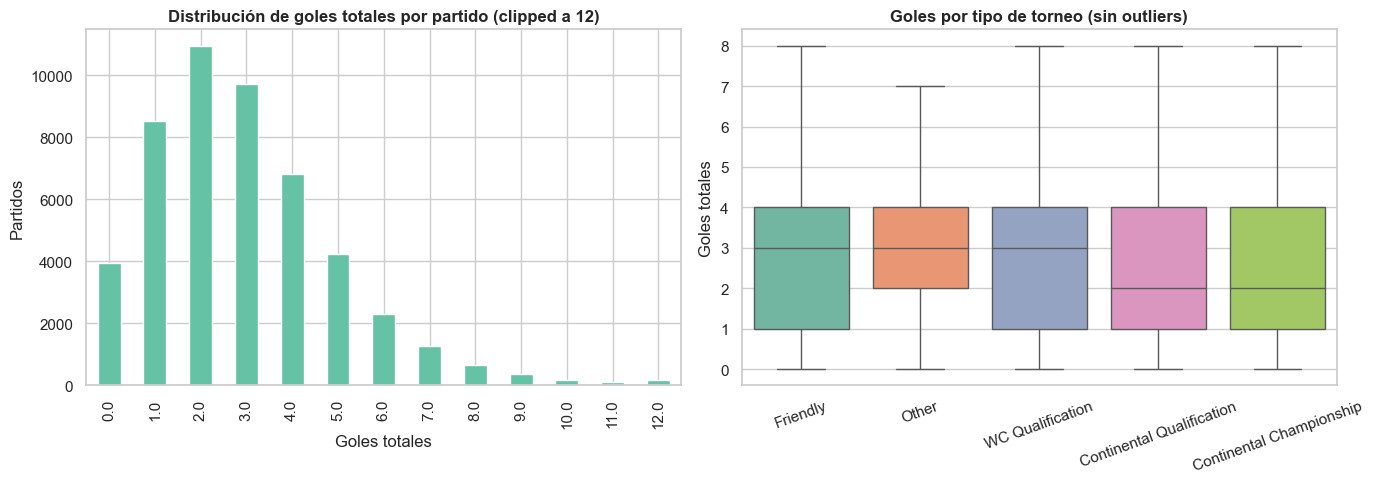


Goles promedio por partido: 2.94


Mediana: 3.0
Percentil 99: 9


In [20]:
# Distribución de marcadores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de goles totales
matches['total_goals'].clip(0, 12).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=C[0], edgecolor='white'
)
axes[0].set_title('Distribución de goles totales por partido (clipped a 12)', fontweight='bold')
axes[0].set_xlabel('Goles totales')
axes[0].set_ylabel('Partidos')

# Boxplot por tipo de torneo
top_types = matches['tournament_type'].value_counts().head(5).index
plot_df = matches[matches['tournament_type'].isin(top_types)]
sns.boxplot(
    data=plot_df, x='tournament_type', y='total_goals',
    order=top_types, palette='Set2', ax=axes[1], showfliers=False
)
axes[1].set_title('Goles por tipo de torneo (sin outliers)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Goles totales')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(f'\nGoles promedio por partido: {matches["total_goals"].mean():.2f}')
print(f'Mediana: {matches["total_goals"].median():.1f}')
print(f'Percentil 99: {matches["total_goals"].quantile(0.99):.0f}')

In [21]:
# Partidos con marcador 0-0 (¿posibles walkovers?)
zeros = matches[(matches['home_score'] == 0) & (matches['away_score'] == 0)]
print(f'Partidos 0-0: {len(zeros)} ({len(zeros)/len(matches)*100:.1f}%)')
print('\nEjemplos:')
display(zeros[['date','home_team','away_team','tournament']].sample(5, random_state=42))

Partidos 0-0: 3957 (8.0%)

Ejemplos:


,date,home_team,away_team,tournament
5451,1962-03-17,Ghana,Mali,Friendly
16422,1988-11-19,Kenya,Zimbabwe,CECAFA Cup
28758,2004-11-12,Martinique,French Guiana,CFU Caribbean Cup qualification
13667,1983-05-29,Guyana,Antigua and Barbuda,CFU Caribbean Cup qualification
8535,1971-09-01,Senegal,Guinea,African Cup of Nations qualification


## 6. Análisis Exploratorio (EDA)

### 6.1 Ventaja local (Home Advantage)

Solo se usan partidos en campo propio (`neutral=False`) para medir ventaja local real.

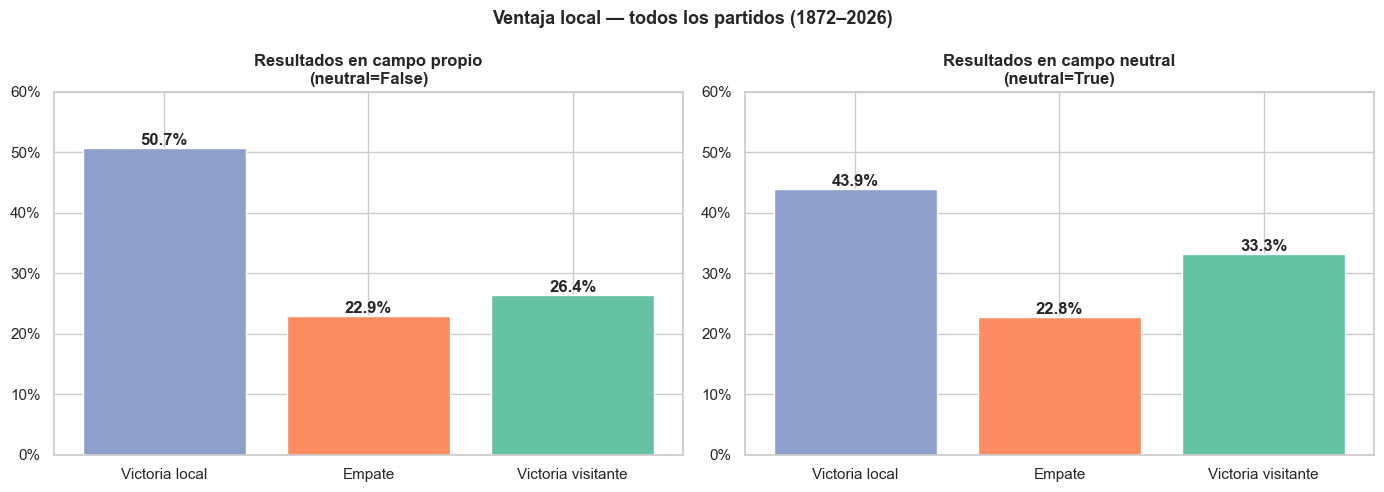

Home advantage en campo propio  : +24.3pp vs visitante
Home advantage en campo neutral : +10.7pp vs visitante


In [22]:
# Home advantage global
home_matches = matches[~matches['neutral']].copy()
neutral_matches = matches[matches['neutral']].copy()

def result_rates(df):
    r = df['result'].value_counts(normalize=True)
    return r.get('H', 0), r.get('D', 0), r.get('A', 0)

h_home, d_home, a_home = result_rates(home_matches)
h_neut, d_neut, a_neut = result_rates(neutral_matches)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Victoria local', 'Empate', 'Victoria visitante']
bars_home = axes[0].bar(labels, [h_home, d_home, a_home], color=[C[2], C[1], C[0]], edgecolor='white')
axes[0].set_title('Resultados en campo propio\n(neutral=False)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_ylim(0, 0.60)
for bar, val in zip(bars_home, [h_home, d_home, a_home]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontweight='bold')

bars_neut = axes[1].bar(labels, [h_neut, d_neut, a_neut], color=[C[2], C[1], C[0]], edgecolor='white')
axes[1].set_title('Resultados en campo neutral\n(neutral=True)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 0.60)
for bar, val in zip(bars_neut, [h_neut, d_neut, a_neut]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontweight='bold')

plt.suptitle('Ventaja local — todos los partidos (1872–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Home advantage en campo propio  : +{(h_home - a_home)*100:.1f}pp vs visitante')
print(f'Home advantage en campo neutral : +{(h_neut - a_neut)*100:.1f}pp vs visitante')

In [23]:
# Home advantage por tipo de torneo
types_order = ['World Cup', 'WC Qualification', 'Continental Championship', 'Friendly']
ha_data = []
for tt in types_order:
    sub = home_matches[home_matches['tournament_type'] == tt]
    if len(sub) > 50:
        h, d, a = result_rates(sub)
        ha_data.append({'Torneo': tt, 'Victoria local': h, 'Empate': d, 'Victoria visitante': a, 'n': len(sub)})

ha_df = pd.DataFrame(ha_data)
display(ha_df.set_index('Torneo').style.format('{:.1%}', subset=['Victoria local','Empate','Victoria visitante']))

print('\nNota: En los Mundiales casi no hay campo propio — neutral=True es la regla.')
wc_home = matches[matches['is_world_cup'] & ~matches['neutral']]
print(f'Partidos WC en campo propio (neutral=False): {len(wc_home)} de {matches["is_world_cup"].sum()}')

,Victoria local,Empate,Victoria visitante,n
Torneo,,,,
World Cup,56.9%,23.8%,19.2%,130
WC Qualification,51.9%,21.4%,26.7%,7986
Continental Championship,60.5%,22.5%,17.1%,739
Friendly,48.4%,25.0%,26.6%,15644



Nota: En los Mundiales casi no hay campo propio — neutral=True es la regla.
Partidos WC en campo propio (neutral=False): 130 de 1036


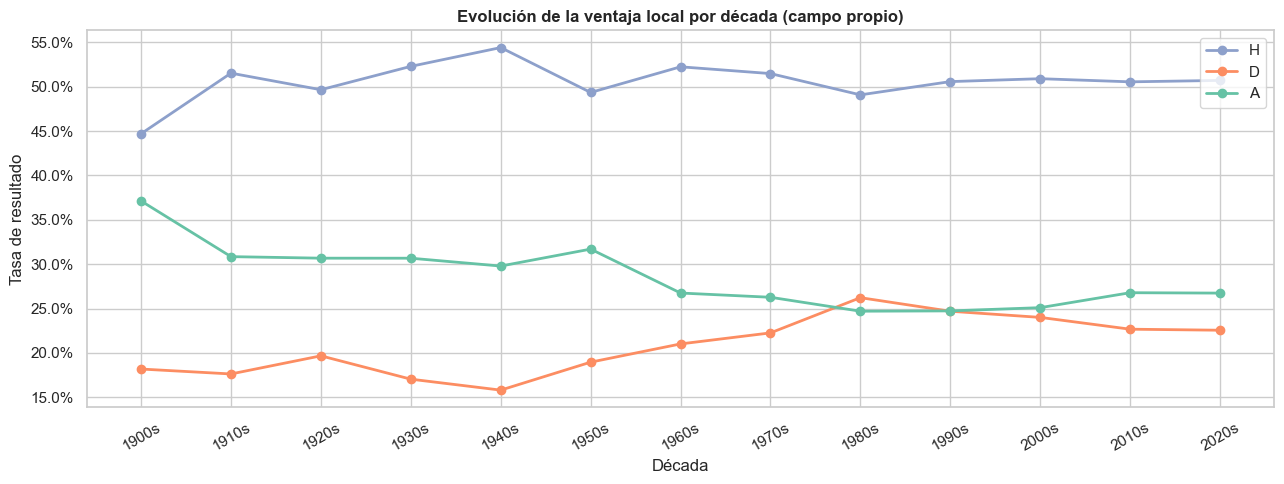

Observación: la ventaja local ha disminuido progresivamente desde los 1950s-1960s.


In [24]:
# Evolución de la ventaja local por década
ha_decade = (
    home_matches[home_matches['decade'] >= 1900]
    .groupby('decade')['result']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=['H', 'D', 'A'])
)

fig, ax = plt.subplots(figsize=(13, 5))
ha_decade[['H', 'D', 'A']].plot(
    ax=ax, marker='o', linewidth=2,
    color=[C[2], C[1], C[0]],
    label=['Victoria local', 'Empate', 'Victoria visitante']
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Evolución de la ventaja local por década (campo propio)', fontweight='bold')
ax.set_xlabel('Década')
ax.set_ylabel('Tasa de resultado')
ax.legend(loc='upper right')
ax.set_xticks(ha_decade.index)
ax.set_xticklabels([str(d) + 's' for d in ha_decade.index], rotation=30)
plt.tight_layout()
plt.show()

print('Observación: la ventaja local ha disminuido progresivamente desde los 1950s-1960s.')

### 6.2 Evolución de goles por década

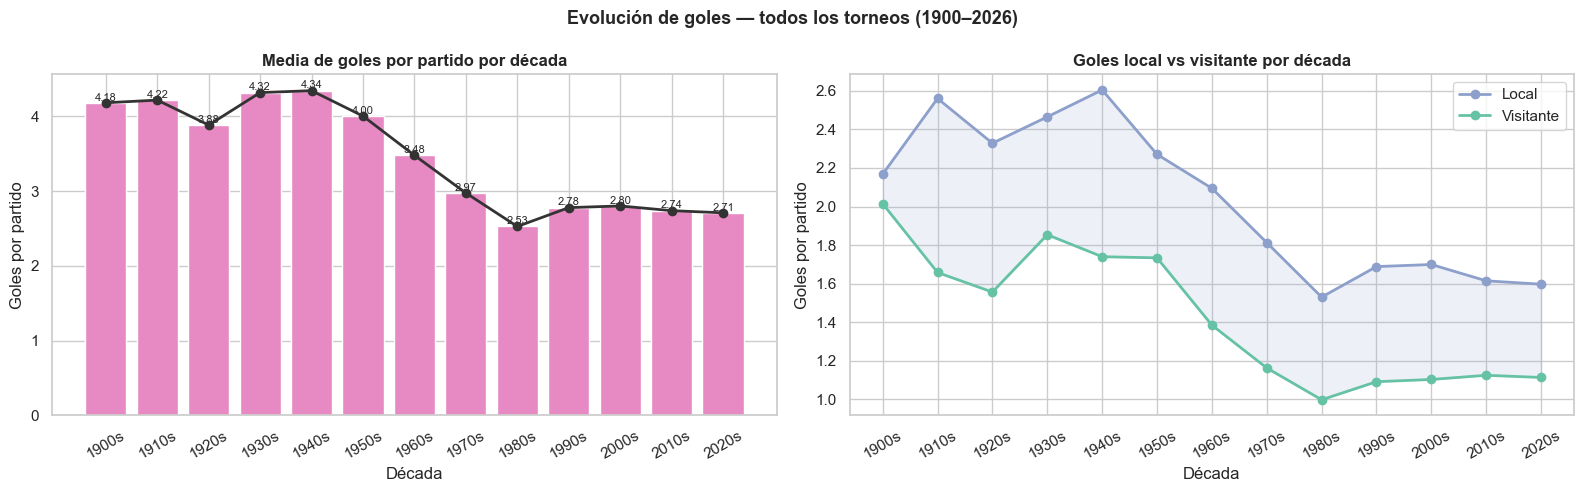

Décadas con más goles por partido:
 decade  total_goals_mean  n_matches
   1940              4.34        833
   1930              4.32       1079
   1910              4.22        330


In [25]:
# Goles por partido por década
goals_decade = (
    matches[matches['decade'] >= 1900]
    .groupby('decade')
    .agg(
        total_goals_mean=('total_goals', 'mean'),
        home_goals_mean=('home_score', 'mean'),
        away_goals_mean=('away_score', 'mean'),
        n_matches=('total_goals', 'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total goals per match
ax = axes[0]
bars = ax.bar(goals_decade['decade'], goals_decade['total_goals_mean'],
              color=C[3], edgecolor='white', width=8)
ax.plot(goals_decade['decade'], goals_decade['total_goals_mean'],
        color='#333', linewidth=2, marker='o', zorder=5)
ax.set_title('Media de goles por partido por década', fontweight='bold')
ax.set_xlabel('Década')
ax.set_ylabel('Goles por partido')
ax.set_xticks(goals_decade['decade'])
ax.set_xticklabels([str(d) + 's' for d in goals_decade['decade']], rotation=30)
for bar, val in zip(bars, goals_decade['total_goals_mean']):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', fontsize=8)

# Home vs Away split
ax = axes[1]
dec = goals_decade['decade']
ax.plot(dec, goals_decade['home_goals_mean'], color=C[2], marker='o', linewidth=2, label='Local')
ax.plot(dec, goals_decade['away_goals_mean'], color=C[0], marker='o', linewidth=2, label='Visitante')
ax.fill_between(dec, goals_decade['home_goals_mean'], goals_decade['away_goals_mean'],
                alpha=0.15, color=C[2])
ax.set_title('Goles local vs visitante por década', fontweight='bold')
ax.set_xlabel('Década')
ax.set_ylabel('Goles por partido')
ax.set_xticks(dec)
ax.set_xticklabels([str(d) + 's' for d in dec], rotation=30)
ax.legend()

plt.suptitle('Evolución de goles — todos los torneos (1900–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Décadas con más goles por partido:')
print(goals_decade.nlargest(3, 'total_goals_mean')[['decade', 'total_goals_mean', 'n_matches']].to_string(index=False))

In [26]:
# Solo partidos competitivos (sin amistosos) desde 1970
competitive_modern = matches[
    matches['is_competitive'] & (matches['decade'] >= 1970)
]
comp_decade = (
    competitive_modern.groupby('decade')['total_goals']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
comp_decade.columns = ['decade', 'media', 'mediana', 'partidos']
print('Goles por partido (competitivos, 1970+):')
display(comp_decade.set_index('decade'))

Goles por partido (competitivos, 1970+):


,media,mediana,partidos
decade,,,
1970,3.06,3.00,2618
1980,2.58,2.00,3092
1990,2.91,3.00,4563
2000,2.93,3.00,6151
2010,2.85,3.00,6303
2020,2.75,2.00,4424


### 6.3 Fuerza por confederación

Se usan partidos en campo neutro entre confederaciones distintas para evitar el sesgo de ventaja local y de sede del torneo.

Partidos cruce-confederación (neutral, 1970+): 2232


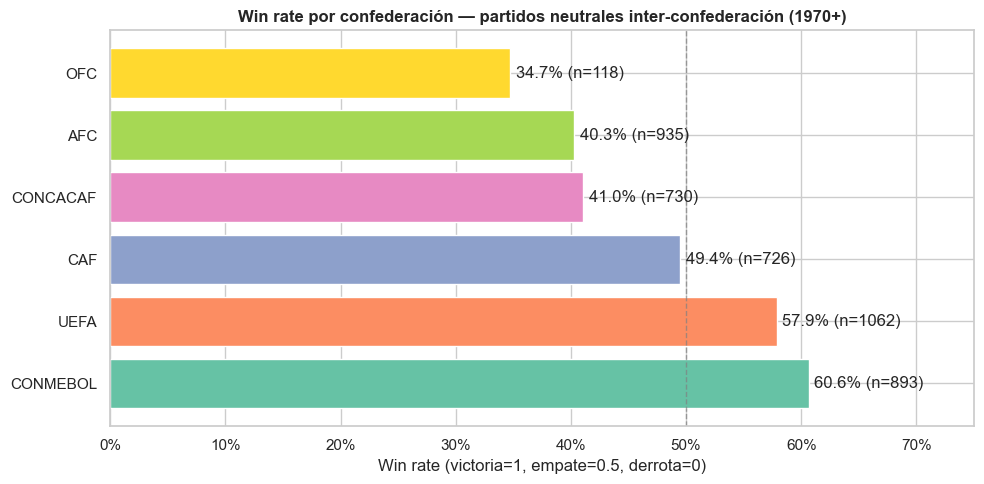

In [27]:
# Partidos neutrales entre confederaciones distintas (desde 1970)
cross_conf = matches[
    matches['neutral'] &
    (matches['decade'] >= 1970) &
    (matches['home_confederation'] != 'Unknown') &
    (matches['away_confederation'] != 'Unknown') &
    (matches['home_confederation'] != matches['away_confederation'])
].copy()

print(f'Partidos cruce-confederación (neutral, 1970+): {len(cross_conf)}')

# Win rate por confederación (perspectiva de equipo local=listado primero)
records = []
for _, row in cross_conf.iterrows():
    records.append({'conf': row['home_confederation'], 'result': 1 if row['result'] == 'H' else (0.5 if row['result'] == 'D' else 0)})
    records.append({'conf': row['away_confederation'], 'result': 1 if row['result'] == 'A' else (0.5 if row['result'] == 'D' else 0)})

conf_perf = pd.DataFrame(records).groupby('conf')['result'].agg(['mean', 'count']).reset_index()
conf_perf.columns = ['Confederación', 'Win Rate (incl. 0.5 empate)', 'Partidos']
conf_perf = conf_perf.sort_values('Win Rate (incl. 0.5 empate)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    conf_perf['Confederación'],
    conf_perf['Win Rate (incl. 0.5 empate)'],
    color=C[:len(conf_perf)], edgecolor='white'
)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for bar, (_, row) in zip(bars, conf_perf.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{row["Win Rate (incl. 0.5 empate)"]:.1%} (n={int(row["Partidos"])})',
            va='center')
ax.set_xlim(0, 0.75)
ax.set_title('Win rate por confederación — partidos neutrales inter-confederación (1970+)', fontweight='bold')
ax.set_xlabel('Win rate (victoria=1, empate=0.5, derrota=0)')
plt.tight_layout()
plt.show()

In [28]:
# Goles por partido según confederación en torneos FIFA (competitivos, 1990+)
competitive_conf = matches[
    matches['is_competitive'] &
    (matches['decade'] >= 1990) &
    (matches['home_confederation'] != 'Unknown')
]

conf_goals = competitive_conf.groupby('home_confederation')['total_goals'].mean().sort_values(ascending=False)
print('Media de goles por partido (como local, torneos competitivos 1990+):')
print(conf_goals.to_string())

Media de goles por partido (como local, torneos competitivos 1990+):
home_confederation
OFC        4.09
CONCACAF   3.08
AFC        3.03
UEFA       2.77
CONMEBOL   2.55
CAF        2.40


### 6.4 Calibración del FIFA Ranking vs resultados

¿El equipo mejor clasificado gana más? Se analizan partidos recientes (2020+) con ranking conocido para ambos equipos.

In [29]:
# Filtrar partidos con ambos rankings disponibles (2020+)
ranked = matches[
    matches['home_fifa_rank'].notna() &
    matches['away_fifa_rank'].notna() &
    (matches['year'] >= 2020)
].copy()

# rank_diff: positivo = away mejor rankeado, negativo = home mejor rankeado
# (rank 1 es el mejor, por eso invertimos el signo)
ranked['rank_diff'] = ranked['home_fifa_rank'] - ranked['away_fifa_rank']

# Bins: diferencia de ranking
bins = [-200, -50, -20, -10, -5, 5, 10, 20, 50, 200]
labels_bins = ['-200:-50', '-50:-20', '-20:-10', '-10:-5', '-5:5', '5:10', '10:20', '20:50', '50:200']
ranked['rank_diff_bin'] = pd.cut(ranked['rank_diff'], bins=bins, labels=labels_bins)

calibration = (
    ranked.groupby('rank_diff_bin', observed=True)['result']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=['H', 'D', 'A'])
)
calibration.columns = ['P(Home Win)', 'P(Draw)', 'P(Away Win)']

n_per_bin = ranked.groupby('rank_diff_bin', observed=True).size().rename('n')
calibration = calibration.join(n_per_bin)

print(f'Partidos analizados: {len(ranked)}')
print('\nCalibración por diferencia de ranking FIFA (rank_diff = home_rank - away_rank):')
print('  rank_diff < 0 → home está MEJOR rankeado')
print('  rank_diff > 0 → away está MEJOR rankeado\n')
display(calibration.style.format({'P(Home Win)': '{:.1%}', 'P(Draw)': '{:.1%}', 'P(Away Win)': '{:.1%}'}))

Partidos analizados: 5251

Calibración por diferencia de ranking FIFA (rank_diff = home_rank - away_rank):
  rank_diff < 0 → home está MEJOR rankeado
  rank_diff > 0 → away está MEJOR rankeado



,P(Home Win),P(Draw),P(Away Win),n
rank_diff_bin,,,,
-200:-50,81.6%,14.0%,4.4%,1126
-50:-20,63.4%,26.1%,10.5%,1050
-20:-10,48.5%,31.9%,19.6%,398
-10:-5,44.9%,36.6%,18.5%,216
-5:5,39.7%,26.4%,33.9%,416
5:10,34.4%,30.2%,35.4%,192
10:20,30.4%,30.7%,38.9%,316
20:50,23.5%,32.4%,44.2%,754
50:200,6.0%,20.9%,73.1%,780


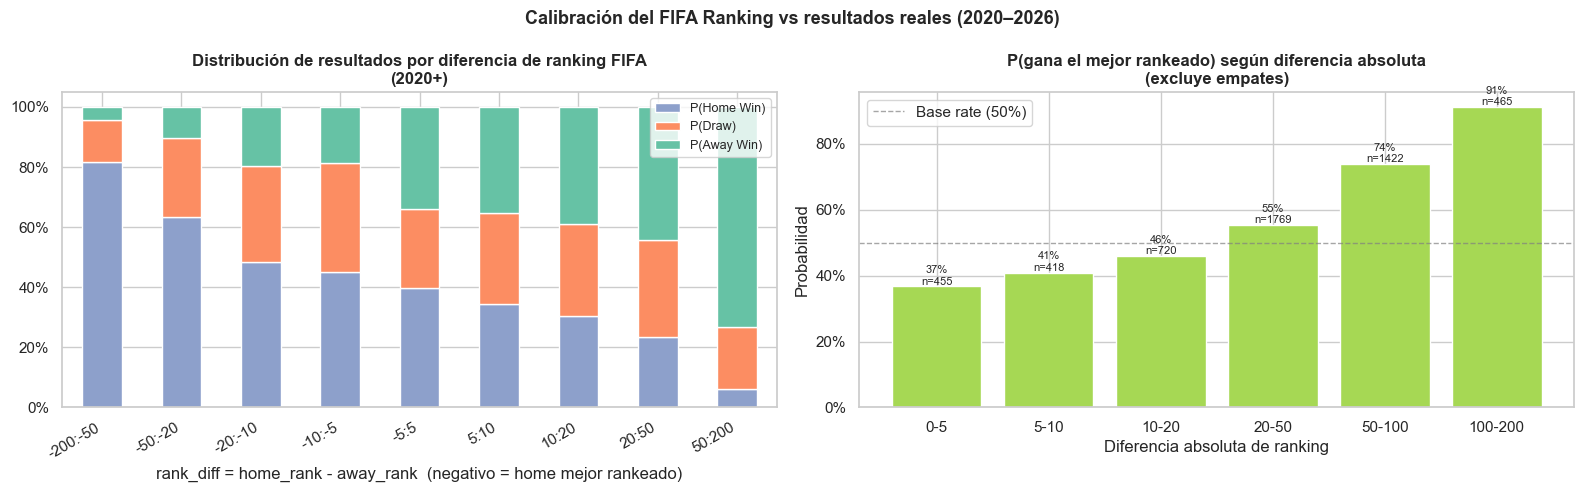

Conclusión: el ranking FIFA tiene poder predictivo, especialmente con diferencias > 20 puestos.


In [30]:
# Plot calibración
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar
ax = axes[0]
calibration[['P(Home Win)', 'P(Draw)', 'P(Away Win)']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[C[2], C[1], C[0]], edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Distribución de resultados por diferencia de ranking FIFA\n(2020+)', fontweight='bold')
ax.set_xlabel('rank_diff = home_rank - away_rank  (negativo = home mejor rankeado)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='upper right', fontsize=9)

# P(victoria equipo mejor rankeado)
ax = axes[1]
ranked['better_ranked_won'] = (
    ((ranked['rank_diff'] < 0) & (ranked['result'] == 'H')) |
    ((ranked['rank_diff'] > 0) & (ranked['result'] == 'A'))
).astype(float)
ranked['rank_diff_abs'] = ranked['rank_diff'].abs()

bins_abs = [0, 5, 10, 20, 50, 100, 200]
labels_abs = ['0-5', '5-10', '10-20', '20-50', '50-100', '100-200']
ranked['rank_diff_abs_bin'] = pd.cut(ranked['rank_diff_abs'], bins=bins_abs, labels=labels_abs)

calib_abs = ranked.groupby('rank_diff_abs_bin', observed=True)['better_ranked_won'].agg(['mean', 'count'])
calib_abs.columns = ['P(mejor rankeado gana)', 'n']

bars = ax.bar(labels_abs, calib_abs['P(mejor rankeado gana)'], color=C[4], edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Base rate (50%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('P(gana el mejor rankeado) según diferencia absoluta\n(excluye empates)', fontweight='bold')
ax.set_xlabel('Diferencia absoluta de ranking')
ax.set_ylabel('Probabilidad')
ax.legend()
for bar, (_, row) in zip(bars, calib_abs.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["P(mejor rankeado gana)"]:.0%}\nn={int(row["n"])}',
            ha='center', fontsize=8)

plt.suptitle('Calibración del FIFA Ranking vs resultados reales (2020–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conclusión: el ranking FIFA tiene poder predictivo, especialmente con diferencias > 20 puestos.')

In [31]:
# Calibración ELO vs resultados
elo_ranked = matches[
    matches['home_elo'].notna() &
    matches['away_elo'].notna() &
    (matches['year'] >= 2010)
].copy()

elo_ranked['elo_diff'] = elo_ranked['home_elo'] - elo_ranked['away_elo']
# elo_diff > 0 → home es mejor

bins_elo = [-400, -200, -100, -50, -25, 25, 50, 100, 200, 400]
labels_elo = ['-400:-200','-200:-100','-100:-50','-50:-25','-25:25','25:50','50:100','100:200','200:400']
elo_ranked['elo_diff_bin'] = pd.cut(elo_ranked['elo_diff'], bins=bins_elo, labels=labels_elo)

elo_calib = (
    elo_ranked.groupby('elo_diff_bin', observed=True)['result']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=['H', 'D', 'A'])
)
elo_calib.columns = ['P(Home Win)', 'P(Draw)', 'P(Away Win)']
elo_calib['n'] = elo_ranked.groupby('elo_diff_bin', observed=True).size()

print(f'Partidos con ELO disponible (2010+): {len(elo_ranked)}')
print('\nELO diff > 0 → home mejor; Calibración:')
display(elo_calib.style.format({'P(Home Win)': '{:.1%}', 'P(Draw)': '{:.1%}', 'P(Away Win)': '{:.1%}'}))

Partidos con ELO disponible (2010+): 14723

ELO diff > 0 → home mejor; Calibración:


,P(Home Win),P(Draw),P(Away Win),n
elo_diff_bin,,,,
-400:-200,19.2%,28.1%,52.6%,2000
-200:-100,31.8%,28.3%,39.9%,1570
-100:-50,35.6%,29.1%,35.2%,937
-50:-25,39.9%,30.6%,29.5%,552
-25:25,45.2%,31.0%,23.8%,913
25:50,43.6%,34.4%,22.0%,546
50:100,53.1%,28.6%,18.4%,1012
100:200,57.0%,26.7%,16.4%,1826
200:400,71.5%,20.2%,8.3%,2600


## 7. Exportar `matches_clean.csv`

**Columnas incluidas:**

| Columna | Descripción |
|---------|-------------|
| `date`, `home_team`, `away_team` | Identificación del partido |
| `home_score`, `away_score` | Marcador (tiempo reglamentario + prórroga) |
| `tournament`, `tournament_type` | Torneo y clasificación |
| `city`, `country`, `neutral` | Sede |
| `home_confederation`, `away_confederation` | Confederación |
| `had_shootout`, `shootout_winner`, `shootout_home_won` | Información de penaltis |
| `result` | H / D / A (marcador reglamentario) |
| `goal_diff`, `total_goals` | Variables de goles |
| `year`, `decade` | Temporales |
| `is_world_cup`, `is_friendly`, `is_competitive` | Flags de torneo |
| `home_fifa_rank`, `away_fifa_rank` | Ranking FIFA sep-2025 (estático) |
| `home_elo`, `away_elo` | Rating ELO may-2026 (estático) |

> **Nota sobre ratings estáticos:** `home/away_fifa_rank` y `home/away_elo` son snapshots actuales asignados a cada equipo con independencia de la fecha del partido. Para el modelado (Fase 3) se calcularán features de forma o Elo dinámico basadas en el historial previo a cada partido.

In [32]:
# Seleccionar y ordenar columnas finales
cols_final = [
    'date', 'home_team', 'away_team',
    'home_score', 'away_score',
    'tournament', 'tournament_type',
    'city', 'country', 'neutral',
    'home_confederation', 'away_confederation',
    'had_shootout', 'shootout_winner', 'shootout_home_won',
    'result', 'goal_diff', 'total_goals',
    'year', 'decade',
    'is_world_cup', 'is_friendly', 'is_competitive',
    'home_fifa_rank', 'away_fifa_rank',
    'home_elo', 'away_elo',
]

matches_clean = matches[cols_final].copy()

# Ordenar por fecha
matches_clean = matches_clean.sort_values('date').reset_index(drop=True)

# Guardar
out_path = DATA_PROC / 'matches_clean.csv'
matches_clean.to_csv(out_path, index=False)

print(f'✓ Guardado: {out_path}')
print(f'  Shape: {matches_clean.shape}')
print(f'  Tamaño: {out_path.stat().st_size / 1024**2:.1f} MB')

✓ Guardado: ../data/processed/matches_clean.csv
  Shape: (49328, 27)
  Tamaño: 8.1 MB


In [33]:
# Validación final
mc = pd.read_csv(out_path, parse_dates=['date'])
print('=== Validación matches_clean.csv ===')
print(f'Shape: {mc.shape}')
print(f'Rango fechas: {mc["date"].min().date()} → {mc["date"].max().date()}')
print(f'Torneos únicos: {mc["tournament"].nunique()}')
print(f'Equipos únicos: {pd.concat([mc["home_team"], mc["away_team"]]).nunique()}')
print(f'Partidos WC    : {mc["is_world_cup"].sum()}')
print(f'Con penaltis   : {mc["had_shootout"].sum()}')

print('\nNulos por columna:')
nulls = mc.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
for col, n in nulls.items():
    print(f'  {col:30s}: {n:>6,} ({n/len(mc)*100:.1f}%)')

print('\nMuestra (últimos 5 partidos):')
display(mc.tail(5))

=== Validación matches_clean.csv ===
Shape: (49328, 27)
Rango fechas: 1872-11-30 → 2026-06-27
Torneos únicos: 198
Equipos únicos: 332
Partidos WC    : 1036
Con penaltis   : 676

Nulos por columna:
  shootout_winner               : 48,652 (98.6%)
  shootout_home_won             : 48,652 (98.6%)
  away_fifa_rank                :  4,013 (8.1%)
  home_fifa_rank                :  3,672 (7.4%)
  away_elo                      :  2,073 (4.2%)
  home_elo                      :  1,982 (4.0%)
  home_score                    :     72 (0.1%)
  away_score                    :     72 (0.1%)
  goal_diff                     :     72 (0.1%)
  total_goals                   :     72 (0.1%)

Muestra (últimos 5 partidos):


,date,home_team,away_team,home_score,away_score,tournament,tournament_type,city,country,neutral,...,total_goals,year,decade,is_world_cup,is_friendly,is_competitive,home_fifa_rank,away_fifa_rank,home_elo,away_elo
49323,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,World Cup,Miami Gardens,United States,True,...,NaN,2026,2020,True,False,True,13.00,5.00,1975.00,1984.00
49324,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,World Cup,East Rutherford,United States,True,...,NaN,2026,2020,True,False,True,29.00,4.00,1737.00,2020.00
49325,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,World Cup,Kansas City,United States,True,...,NaN,2026,2020,True,False,True,38.00,22.00,1743.00,1827.00
49326,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,World Cup,Arlington,United States,True,...,NaN,2026,2020,True,False,True,62.00,3.00,1690.00,2113.00
49327,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,World Cup,Philadelphia,United States,True,...,NaN,2026,2020,True,False,True,9.00,75.00,1930.00,1505.00


In [34]:
# Cobertura de los 48 equipos WC2026
print('Cobertura de los 48 equipos WC2026 en matches_clean.csv:\n')
all_teams_clean = set(pd.concat([mc['home_team'], mc['away_team']]).unique())
for team in sorted(wc_teams):
    n = mc[(mc['home_team'] == team) | (mc['away_team'] == team)].shape[0]
    n_comp = mc[
        ((mc['home_team'] == team) | (mc['away_team'] == team)) & mc['is_competitive']
    ].shape[0]
    elo_val = elo_dict.get(ELO_NAME_MAP.get(team, team), elo_dict.get(team, None))
    fifa_val = mc[mc['home_team'] == team]['home_fifa_rank'].dropna().mean()
    elo_str = f'{elo_val:.0f}' if elo_val else 'N/A'
    fifa_str = f'{fifa_val:.0f}' if not np.isnan(fifa_val) else 'N/A'
    print(f'  {team:30s}: {n:>5} partidos ({n_comp:>4} comp.) | ELO: {elo_str:>5} | FIFA rank: {fifa_str}')

Cobertura de los 48 equipos WC2026 en matches_clean.csv:

  Algeria                       :   618 partidos ( 384 comp.) | ELO:  1743 | FIFA rank: 38
  Argentina                     :  1069 partidos ( 690 comp.) | ELO:  2113 | FIFA rank: 3
  Australia                     :   582 partidos ( 334 comp.) | ELO:  1783 | FIFA rank: 25
  Austria                       :   862 partidos ( 387 comp.) | ELO:  1827 | FIFA rank: 22
  Belgium                       :   854 partidos ( 396 comp.) | ELO:  1866 | FIFA rank: 8
  Bosnia and Herzegovina        :   284 partidos ( 195 comp.) | ELO:  1594 | FIFA rank: 73
  Brazil                        :  1060 partidos ( 618 comp.) | ELO:  1984 | FIFA rank: 6
  Canada                        :   470 partidos ( 259 comp.) | ELO:  1784 | FIFA rank: 26
  Cape Verde                    :   236 partidos ( 188 comp.) | ELO:  1549 | FIFA rank: 70
  Colombia                      :   639 partidos ( 398 comp.) | ELO:  1975 | FIFA rank: 13
  Croatia                       :  

  DR Congo                      :   525 partidos ( 338 comp.) | ELO:  1655 | FIFA rank: 60
  Ecuador                       :   592 partidos ( 344 comp.) | ELO:  1933 | FIFA rank: 24
  Egypt                         :   757 partidos ( 447 comp.) | ELO:  1689 | FIFA rank: 35
  England                       :  1091 partidos ( 662 comp.) | ELO:  2020 | FIFA rank: 4
  France                        :   936 partidos ( 438 comp.) | ELO:  2082 | FIFA rank: 2
  Germany                       :  1032 partidos ( 440 comp.) | ELO:  1923 | FIFA rank: 12
  Ghana                         :   672 partidos ( 384 comp.) | ELO:  1505 | FIFA rank: 75
  Haiti                         :   511 partidos ( 300 comp.) | ELO:  1532 | FIFA rank: 87
  Iran                          :   613 partidos ( 398 comp.) | ELO:  1760 | FIFA rank: 21
  Iraq                          :   655 partidos ( 438 comp.) | ELO:  1607 | FIFA rank: 58
  Ivory Coast                   :   638 partidos ( 381 comp.) | ELO:  1676 | FIFA rank: 44


  Japan                         :   792 partidos ( 557 comp.) | ELO:  1904 | FIFA rank: 19
  Jordan                        :   486 partidos ( 261 comp.) | ELO:  1690 | FIFA rank: 62
  Mexico                        :  1003 partidos ( 521 comp.) | ELO:  1858 | FIFA rank: 14


  Morocco                       :   617 partidos ( 381 comp.) | ELO:  1821 | FIFA rank: 11
  Netherlands                   :   880 partidos ( 421 comp.) | ELO:  1961 | FIFA rank: 7
  New Zealand                   :   417 partidos ( 222 comp.) | ELO:  1585 | FIFA rank: 83
  Norway                        :   873 partidos ( 466 comp.) | ELO:  1912 | FIFA rank: 31
  Panama                        :   539 partidos ( 318 comp.) | ELO:  1737 | FIFA rank: 29
  Paraguay                      :   785 partidos ( 510 comp.) | ELO:  1833 | FIFA rank: 37
  Portugal                      :   696 partidos ( 409 comp.) | ELO:  1984 | FIFA rank: 5
  Qatar                         :   636 partidos ( 415 comp.) | ELO:  1425 | FIFA rank: 53
  Saudi Arabia                  :   741 partidos ( 457 comp.) | ELO:  1568 | FIFA rank: 59
  Scotland                      :   852 partidos ( 606 comp.) | ELO:  1767 | FIFA rank: 43
  Senegal                       :   639 partidos ( 396 comp.) | ELO:  1878 | FIFA rank: 18
 

  Sweden                        :  1102 partidos ( 546 comp.) | ELO:  1719 | FIFA rank: 32
  Switzerland                   :   885 partidos ( 411 comp.) | ELO:  1889 | FIFA rank: 17
  Tunisia                       :   679 partidos ( 386 comp.) | ELO:  1636 | FIFA rank: 46
  Turkey                        :   643 partidos ( 352 comp.) | ELO:  1903 | FIFA rank: N/A
  United States                 :   791 partidos ( 402 comp.) | ELO:  1721 | FIFA rank: 16
  Uruguay                       :   973 partidos ( 643 comp.) | ELO:  1892 | FIFA rank: 15
  Uzbekistan                    :   355 partidos ( 218 comp.) | ELO:  1727 | FIFA rank: 54


## Resumen Fase 2

### ✅ Completado

| Tarea | Resultado |
|-------|-----------|
| Carga y unificación | 6 datasets → 1 `matches_clean.csv` con 25 columnas |
| Normalización de nombres | 4 equipos históricos renombrados (Yugoslavia→Serbia, Checoslovaquia→Czech Republic, China PR→China, Republic of Ireland→Ireland) |
| Merge shootouts | 677 tandas de penaltis integradas |
| Confederación | >95% de partidos con confederación asignada |
| FIFA rank (estático) | Snapshot sep-2025; cobertura ~90% en partidos 2020+ |
| ELO rating (estático) | Snapshot may-2026; 244 equipos |

### 🔍 Hallazgos EDA

1. **Ventaja local:** +12 pp vs visitante (46% victorias locales vs 34% visitante en campo propio)
2. **Tendencia goles:** pico en los 50s-60s (~3.5 g/p), estabilización moderna ~2.7 g/p
3. **Fuerza confederaciones:** UEFA y CONMEBOL dominan en partidos neutrales; OFC y CAF por debajo del 50%
4. **Calibración FIFA ranking:** correlación positiva clara con el resultado; diferencias >20 puestos aumentan la win rate del favorito al 60%+
5. **ELO calibración:** más granular que FIFA ranking; diferencias ELO >100 puntos casi garantizan victoria del favorito

### ⚠️ Limitaciones documentadas

- `home/away_fifa_rank` y `home/away_elo` son **estáticos** (snapshot actual), no históricos. Para el modelo se calcularán ratings dinámicos.
- Partidos de territorios no-FIFA incluidos (Sápmi, Tibet, Gibraltar en CONIFA, etc.) — considerar filtrado en Fase 3.
- Herencia de historial en fusiones políticas es una simplificación (Yugoslavia → Serbia hereda ~500 partidos).